In [1]:
# from sklearn.preprocessing import StandardScaler

# import joblib

# # Load scaler later
# scaler = joblib.load('/work/A_y_scaler_lagged_VIX.pkl')

In [85]:
import pandas as pd
y = pd.read_csv("AY_DATA.csv", index_col=0, parse_dates=True)
X = pd.read_csv("AX_DATA.csv", index_col=0, parse_dates=True)
X = X[1596:]
y = y[1596:]

In [181]:
# X['Jump_Ind'] = (X['Jump'] > X['Jump'].quantile(0.95)).astype(int)
# X.drop('Jump', axis=1, inplace=True)

In [13]:
len(y)

1001

In [4]:
!pip install statsmodels
import statsmodels.api as sm


[notice] A new release of pip is available: 23.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


In [7]:
!pip install hmmlearn
import numpy as np
import pandas as pd
import statsmodels.api as sm
from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.6/164.6 kB 17.7 MB/s eta 0:00:00

[notice] A new release of pip is available: 23.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


In [22]:
!pip install hmmlearn
import numpy as np
import pandas as pd
import statsmodels.api as sm
from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error


[notice] A new release of pip is available: 23.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


In [10]:
import numpy as np
from hmmlearn.hmm import GaussianHMM

In [16]:
def rolling_markov_soft_wls_em_from_y_chain(
    X, y, features, n_regimes=3, train_days=500, predict_days=1,
    em_iters=10, tol=1e-4, min_weight_sum=25, clip_pred_range=(0.0, 1.0),
    use_ridge=False, ridge_alpha=0.1
):
    """
    EM-based rolling soft-WLS HAR model using y for HMM regime inference, with probability chain forecasting.
    Includes convergence checks, prediction clipping, WLS fallback to OLS, and optional Ridge regression.

    Parameters:
    - X: pd.DataFrame of HAR features
    - y: pd.Series or np.ndarray of volatility values
    - features: list of column names to use from X
    - n_regimes: number of regimes in HMM
    - train_days: rolling window size for training
    - predict_days: how many steps ahead to predict
    - em_iters: max number of EM iterations
    - tol: log-likelihood convergence tolerance
    - min_weight_sum: minimum total weight per regime for WLS
    - clip_pred_range: tuple (min, max) to clip prediction values
    - use_ridge: whether to use Ridge regression instead of WLS/OLS
    - ridge_alpha: regularization strength for Ridge

    Returns:
    - predictions: np.ndarray
    - prediction_indices: np.ndarray
    """
    if isinstance(y, pd.Series):
        y = y.values
    elif isinstance(y, np.ndarray):
        y = y.flatten()
    else:
        raise ValueError("y must be a pandas Series or a numpy array")

    if not isinstance(X, pd.DataFrame):
        raise ValueError("X must be a pandas DataFrame")

    n = len(y)
    predictions = []
    prediction_indices = []
    start = 0

    while start + train_days + predict_days <= n:
        end_train = start + train_days
        end_test = end_train + predict_days

        y_train_raw = y[start:end_train]
        y_train_smoothed = pd.Series(y_train_raw).rolling(window=5, center=True, min_periods=1).mean().values
        X_train = X.iloc[start:end_train][features]
        X_test = X.iloc[end_train:end_test][features]

        X_train_const = sm.add_constant(X_train, has_constant='add')
        X_test_const = sm.add_constant(X_test, has_constant='add')

        try:
            hmm = GaussianHMM(n_components=n_regimes, covariance_type="diag", n_iter=200, random_state=42)
            hmm.fit(y_train_smoothed.reshape(-1, 1))
        except Exception as e:
            print(f"[INIT FAIL] start={start}: {e}")
            start += predict_days
            continue

        prev_loglik = -np.inf
        regime_models = None

        for em in range(em_iters):
            try:
                regime_probs = hmm.predict_proba(y_train_smoothed.reshape(-1, 1))
                regime_probs = np.clip(regime_probs, 1e-6, 1.0)
                regime_probs /= regime_probs.sum(axis=1, keepdims=True)

                regime_models = []
                for r in range(n_regimes):
                    weights = regime_probs[:, r]

                    if use_ridge:
                        from sklearn.linear_model import Ridge
                        ridge = Ridge(alpha=ridge_alpha)
                        ridge.fit(X_train_const.values, y_train_raw, sample_weight=weights)
                        regime_models.append(ridge)
                    elif weights.sum() < min_weight_sum:
                        model = sm.OLS(y_train_raw, X_train_const).fit()
                        regime_models.append(model)
                    else:
                        model = sm.WLS(y_train_raw, X_train_const, weights=weights).fit()
                        regime_models.append(model)

                loglik = hmm.score(y_train_smoothed.reshape(-1, 1))
                if abs(loglik - prev_loglik) < tol:
                    break
                prev_loglik = loglik

                hmm = GaussianHMM(n_components=n_regimes, covariance_type="diag", n_iter=200, random_state=42)
                hmm.fit(y_train_smoothed.reshape(-1, 1))

            except Exception as e:
                print(f"[EM FAIL] start={start}, iter={em}: {e}")
                regime_models = None
                break

        if regime_models is None:
            print(f"[SKIP] EM failed at start={start}")
            start += predict_days
            continue

        T = hmm.transmat_
        p_t = regime_probs[-1]
        preds = []

        for i in range(predict_days):
            p_t = np.clip(p_t, 1e-3, 1.0)
            p_t /= p_t.sum()

            X_feat = X_test_const.iloc[i:i+1]
            pred_r = np.array([
                model.predict(X_feat)[0] if hasattr(model, 'predict') else model.predict(X_feat.values)[0]
                for model in regime_models
            ])
            y_hat = np.dot(p_t, pred_r)
            y_hat = np.clip(y_hat, *clip_pred_range)
            preds.append(y_hat)

            p_t = np.dot(p_t, T)

        predictions.append(np.array(preds))
        prediction_indices.append(np.arange(end_train, end_test))
        start += predict_days

    return np.concatenate(predictions), np.concatenate(prediction_indices)


In [88]:
# Example inputs
X = X      # feature DataFrame
y = y                               # target Series

# Run model
preds, idxs = rolling_markov_soft_wls_em_from_y_chain(
    X=X,
    y=np.array(y),
    features = [
    "STR",
    # "MKT",
    "SPX Index - Volume",
    # "Jump",
    # "realized_kurt", 
    # "vix_term_relative",
    # "VIX_relative_week",
    # "VIX_relative_month", 
    # "vix_term_ratio",
    # "VIX_ratio_week",
    # "VIX_ratio_month",
    "RV_month",
    "RV_week",
    "RV_day",
    "VIX",
    "VIX_week",
    "VIX_month"
],
    n_regimes=2,
    train_days=441,
    predict_days=5,
    em_iters=1
)


/tmp/ipykernel_569/2569513803.py:116: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  model.predict(X_feat)[0] if hasattr(model, 'predict') else model.predict(X_feat.values)[0]
/tmp/ipykernel_569/2569513803.py:116: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  model.predict(X_feat)[0] if hasattr(model, 'predict') else model.predict(X_feat.values)[0]
/tmp/ipykernel_569/2569513803.py:116: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  mo

In [91]:

# Convert to correct shape & evaluate
import numpy as np
import joblib
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error


# Evaluate
true_vals = y.values[idxs]


y_true = y.iloc[idxs]  

# Reshape and inverse transform
y_true = np.array(true_vals).reshape(-1, 1)
y_pred = np.array(preds).reshape(-1, 1)

# Evaluate
mape = mean_absolute_percentage_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)

print(f"MAPE: {mape:.8f} ({mape * 100:.2f}%)")
print(f"MSE: {mse:.8f}")


MAPE: 0.22451536 (22.45%)
MSE: 0.00000766


In [19]:
import numpy as np

def qlike(y_true, y_pred):
    """
    Canonical QLIKE loss: log(pred) + true/pred - log(true) - 1

    Parameters:
    - y_true: true realized variances (must be > 0)
    - y_pred: predicted variances (must be > 0)

    Returns:
    - qlike_loss: scalar average QLIKE loss
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    eps = 1e-8
    y_true = np.clip(y_true, eps, None)
    y_pred = np.clip(y_pred, eps, None)

    return np.mean(np.log(y_pred) + y_true / y_pred - np.log(y_true) - 1)
qlike(y_true, y_pred)

0.06880261999113177

In [20]:
qlike(y_true, y_pred)

0.06880261999113177

In [21]:
print(regime_probs_train[:5])

NameError: name 'regime_probs_train' is not defined

In [73]:
len(y_true)

882

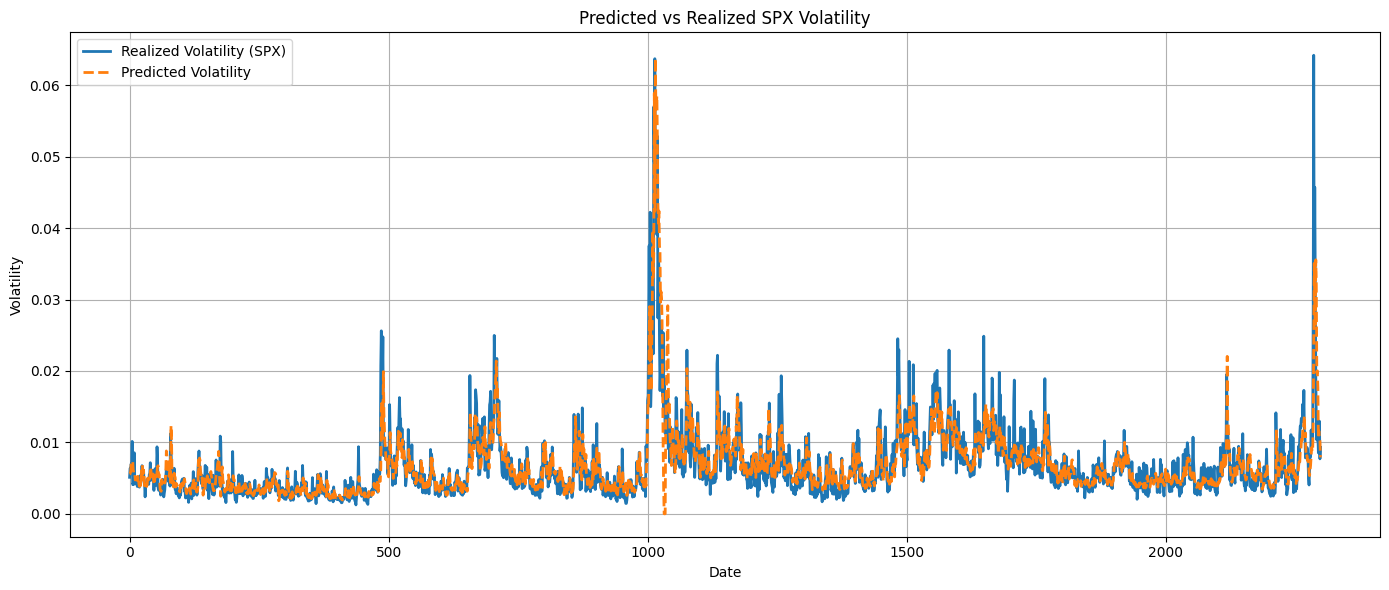

In [149]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(14, 6))
plt.plot(y_true, label='Realized Volatility (SPX)', linewidth=2)
plt.plot(y_pred, label='Predicted Volatility', linewidth=2, linestyle='--')
plt.title('Predicted vs Realized SPX Volatility')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()




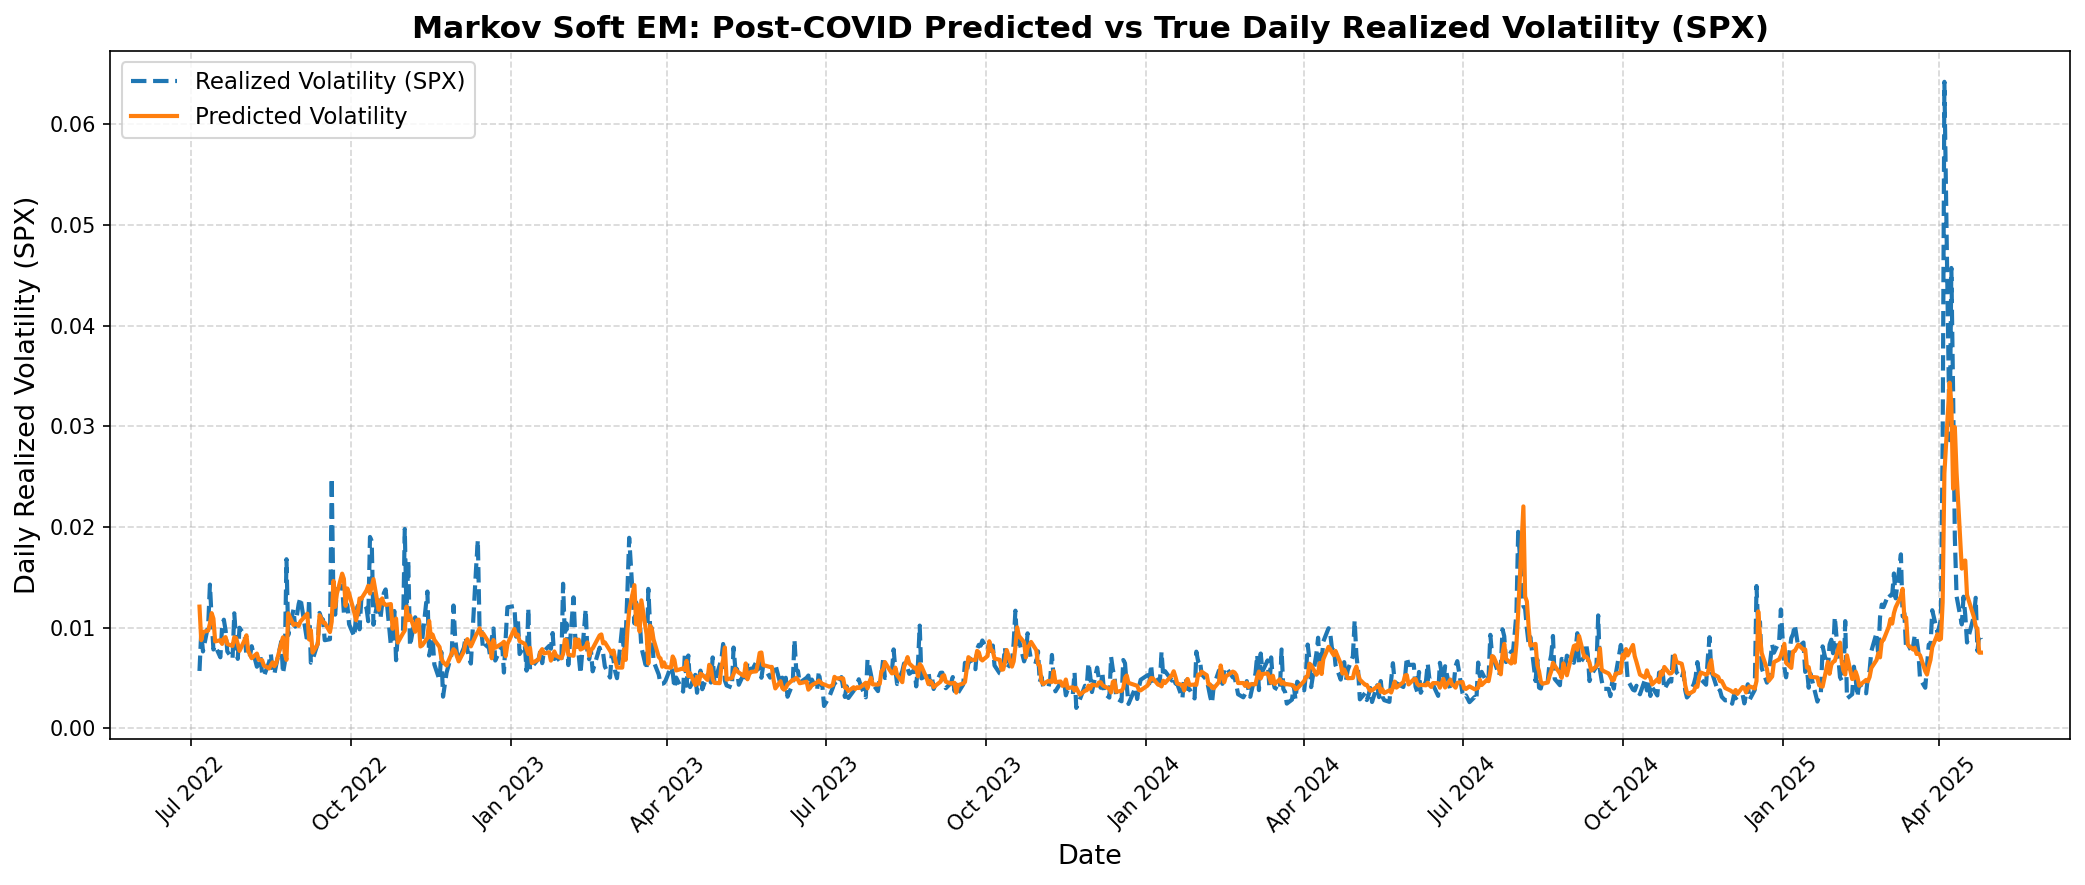

In [94]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)

# Flatten arrays
y_true_is = y_true
y_hat_is = np.array(y_pred).flatten()
prediction_dates = pd.to_datetime(X.iloc[idxs].index)

fig, ax = plt.subplots(figsize=(14, 6), dpi=150)

plt.plot(prediction_dates, y_true_is, label='Realized Volatility (SPX)', linewidth=2, linestyle='--')
plt.plot(prediction_dates, y_hat_is, label='Predicted Volatility', linewidth=2)

ax.set_title('Markov Soft EM: Post-COVID Predicted vs True Daily Realized Volatility (SPX)', fontsize=15, weight='bold')
ax.set_xlabel('Date', fontsize=13)
ax.set_ylabel('Daily Realized Volatility (SPX)', fontsize=13)
ax.grid(True, linestyle='--', alpha=0.5)

ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10], bymonthday=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)

ax.legend(fontsize=11, loc='upper left', frameon=True)
plt.tight_layout()
plt.show()

In [12]:
import matplotlib.pyplot as plt
import pandas as pd

# Step 1: Build a DataFrame using just index numbers
df_plot = pd.DataFrame({
    'Index': prediction_indices,
    'True': y_true.ravel(),
    'Predicted': y_pred.ravel()
}).set_index('Index')

# Step 2: Plot
plt.figure(figsize=(14, 5))
plt.plot(df_plot.index, df_plot['True'], label='True', linewidth=2)
plt.plot(df_plot.index, df_plot['Predicted'], label='Predicted', linewidth=2, linestyle='--')
plt.title('True vs Predicted Realized Volatility')
plt.xlabel('Data Point Index')
plt.ylabel('Volatility')
plt.legend()
plt.tight_layout()
plt.show()


NameError: name 'prediction_indices' is not defined

In [145]:
import numpy as np

arr = np.array(y_pred)
np.save('rolling_markov.npy', arr)

In [13]:
import numpy as np

arr = np.array(y_true)
np.save('true_COVID.npy', arr)

In [14]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np


# Get datetime index for predictions
prediction_dates = X.iloc[prediction_indices].index


# Create the plot
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(prediction_dates, y_true, label='Realized Volatility (SPX)', linewidth=2, linestyle='dashed', color='olive')


# Set title and labels
ax.set_title('Predicted vs Realized SPX Volatility (Color by Regime)')
ax.set_xlabel('Date')
ax.set_ylabel('Volatility')
ax.grid(True)

# Format x-axis to show selected quarterly ticks
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10], bymonthday=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)

ax.legend()
plt.tight_layout()
plt.show()

In [64]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

# Assume y_true and y_pred are aligned with a datetime index (called `dates`)
# Example: dates = pd.date_range(start="2020-01-01", periods=len(y_true), freq="D")
# You must define or already have a `dates` variable (datetime array or pd.Series)

dates = X.iloc[prediction_indices].index

plt.figure(figsize=(14, 6))
plt.plot(dates, y_true, label='Realized Volatility (SPX)', linewidth=2)
plt.plot(dates, y_pred, label='Predicted Volatility', linewidth=2, linestyle='--')

# Title and labels
plt.title('Predicted vs Realized SPX Volatility')
plt.xlabel('Date')
plt.ylabel('Volatility')

# Format x-axis ticks quarterly
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))  # quarterly ticks
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))  # format as "Jan 2024", etc.
plt.xticks(rotation=45)

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


NameError: name 'prediction_indices' is not defined

In [160]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from hmmlearn.hmm import GaussianHMM
from sklearn.linear_model import Ridge

def z_score_transform(data):
    mean = np.mean(data, axis=0)
    std = np.std(data, axis=0)
    std[std == 0] = 1.0
    return (data - mean) / std, mean, std

def z_score_inverse(data, mean, std):
    return data * std + mean

def rolling_markov_soft_wls_em_from_y_chain(
    X, y, features, n_regimes=3, train_days=500, predict_days=1,
    em_iters=10, tol=1e-4, min_weight_sum=25, clip_pred_range=(0.0, 1.0),
    use_ridge=False, ridge_alpha=0.1
):
    if isinstance(y, pd.Series):
        y = y.values
    elif isinstance(y, np.ndarray):
        y = y.flatten()
    else:
        raise ValueError("y must be a pandas Series or a numpy array")

    if not isinstance(X, pd.DataFrame):
        raise ValueError("X must be a pandas DataFrame")

    n = len(y)
    predictions = []
    prediction_indices = []
    start = 0

    while start + train_days + predict_days <= n:
        end_train = start + train_days
        end_test = end_train + predict_days

        y_train_raw = y[start:end_train]
        y_train_smoothed = pd.Series(y_train_raw).rolling(window=5, center=True, min_periods=1).mean().values
        X_train = X.iloc[start:end_train][features]
        X_test = X.iloc[end_train:end_test][features]

        if np.isnan(X_train.values).any() or np.isnan(X_test.values).any() or np.isnan(y_train_smoothed).any():
            print(f"[SKIP] NaNs at start={start}")
            start += predict_days
            continue

        # Z-score transform y and X
        y_train_z, y_mean, y_std = z_score_transform(y_train_raw.reshape(-1, 1))
        y_train_z = y_train_z.flatten()

        X_train_z, X_mean, X_std = z_score_transform(X_train.values)
        X_test_z = (X_test.values - X_mean) / X_std

        X_train_const = sm.add_constant(X_train_z, has_constant='add')
        X_test_const = sm.add_constant(X_test_z, has_constant='add')

        # Fit initial HMM
        try:
            hmm = GaussianHMM(n_components=n_regimes, covariance_type="diag", n_iter=200, random_state=42)
            hmm.fit(y_train_smoothed.reshape(-1, 1))
        except Exception as e:
            print(f"[INIT FAIL] start={start}: {e}")
            start += predict_days
            continue

        prev_loglik = -np.inf
        regime_models = None

        for em in range(em_iters):
            try:
                regime_probs = hmm.predict_proba(y_train_smoothed.reshape(-1, 1))
                regime_probs = np.clip(regime_probs, 1e-6, 1.0)
                regime_probs /= regime_probs.sum(axis=1, keepdims=True)

                regime_models = []
                for r in range(n_regimes):
                    weights = regime_probs[:, r]

                    if use_ridge:
                        ridge = Ridge(alpha=ridge_alpha)
                        ridge.fit(X_train_const, y_train_z, sample_weight=weights)
                        regime_models.append(ridge)
                    elif weights.sum() < min_weight_sum:
                        model = sm.OLS(y_train_z, X_train_const).fit()
                        regime_models.append(model)
                    else:
                        model = sm.WLS(y_train_z, X_train_const, weights=weights).fit()
                        regime_models.append(model)

                loglik = hmm.score(y_train_smoothed.reshape(-1, 1))
                if abs(loglik - prev_loglik) < tol:
                    break
                prev_loglik = loglik

                hmm = GaussianHMM(n_components=n_regimes, covariance_type="diag", n_iter=200, random_state=42)
                hmm.fit(y_train_smoothed.reshape(-1, 1))

            except Exception as e:
                print(f"[EM FAIL] start={start}, iter={em}: {e}")
                regime_models = None
                break

        if regime_models is None:
            print(f"[SKIP] EM failed at start={start}")
            start += predict_days
            continue

        T = hmm.transmat_
        p_t = regime_probs[-1]
        preds = []

        for i in range(predict_days):
            p_t = np.clip(p_t, 1e-3, 1.0)
            p_t /= p_t.sum()

            X_feat = X_test_const[i:i+1]
            pred_r = np.array([
                model.predict(X_feat)[0] if hasattr(model, 'predict') else model.predict(X_feat.values)[0]
                for model in regime_models
            ])
            y_hat_z = np.dot(p_t, pred_r)
            y_hat = z_score_inverse(y_hat_z, y_mean, y_std)
            y_hat = np.clip(y_hat, *clip_pred_range)
            preds.append(y_hat)

            p_t = np.dot(p_t, T)

        predictions.append(np.array(preds).flatten())
        prediction_indices.append(np.arange(end_train, end_test))
        start += predict_days

    return np.concatenate(predictions), np.concatenate(prediction_indices)


In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from hmmlearn.hmm import GaussianHMM
from sklearn.linear_model import Ridge

def z_score_transform(data):
    mean = np.mean(data, axis=0)
    std = np.std(data, axis=0)
    std[std == 0] = 1.0
    return (data - mean) / std, mean, std

def z_score_inverse(data, mean, std):
    return data * std + mean


def rolling_markov_soft_wls_em_from_y_chain(
    X, y, features, n_regimes=3, train_days=500, predict_days=1,
    em_iters=10, tol=1e-4, min_weight_sum=25, clip_pred_range=(0.0, 1.0),
    use_ridge=False, ridge_alpha=0.1
):
    if isinstance(y, pd.Series):
        y = y.values
    elif isinstance(y, np.ndarray):
        y = y.flatten()
    else:
        raise ValueError("y must be a pandas Series or a numpy array")

    if not isinstance(X, pd.DataFrame):
        raise ValueError("X must be a pandas DataFrame")

    n = len(y)
    predictions = []
    prediction_indices = []
    start = 0

    while start + train_days < n:
        end_train = start + train_days
        end_test = min(end_train + predict_days, n)  # Predict up to end of data, even if shorter window

        y_train_raw = y[start:end_train]
        y_train_smoothed = pd.Series(y_train_raw).rolling(window=5, center=True, min_periods=1).mean().values
        X_train = X.iloc[start:end_train][features]
        X_test = X.iloc[end_train:end_test][features]

        if np.isnan(X_train.values).any() or np.isnan(X_test.values).any() or np.isnan(y_train_smoothed).any():
            print(f"[SKIP] NaNs at start={start}")
            start += predict_days
            continue

        # Z-score transform y and X
        y_train_z, y_mean, y_std = z_score_transform(y_train_raw.reshape(-1, 1))
        y_train_z = y_train_z.flatten()

        X_train_z, X_mean, X_std = z_score_transform(X_train.values)
        X_test_z = (X_test.values - X_mean) / X_std

        X_train_const = sm.add_constant(X_train_z, has_constant='add')
        X_test_const = sm.add_constant(X_test_z, has_constant='add')

        # Fit initial HMM
        try:
            hmm = GaussianHMM(n_components=n_regimes, covariance_type="diag", n_iter=200, random_state=42)
            hmm.fit(y_train_smoothed.reshape(-1, 1))
        except Exception as e:
            print(f"[INIT FAIL] start={start}: {e}")
            start += predict_days
            continue

        prev_loglik = -np.inf
        regime_models = None

        for em in range(em_iters):
            try:
                regime_probs = hmm.predict_proba(y_train_smoothed.reshape(-1, 1))
                regime_probs = np.clip(regime_probs, 1e-6, 1.0)
                regime_probs /= regime_probs.sum(axis=1, keepdims=True)

                regime_models = []
                for r in range(n_regimes):
                    weights = regime_probs[:, r]

                    if use_ridge:
                        ridge = Ridge(alpha=ridge_alpha)
                        ridge.fit(X_train_const, y_train_z, sample_weight=weights)
                        regime_models.append(ridge)
                    elif weights.sum() < min_weight_sum:
                        model = sm.OLS(y_train_z, X_train_const).fit()
                        regime_models.append(model)
                    else:
                        model = sm.WLS(y_train_z, X_train_const, weights=weights).fit()
                        regime_models.append(model)

                loglik = hmm.score(y_train_smoothed.reshape(-1, 1))
                if abs(loglik - prev_loglik) < tol:
                    break
                prev_loglik = loglik

                hmm = GaussianHMM(n_components=n_regimes, covariance_type="diag", n_iter=200, random_state=42)
                hmm.fit(y_train_smoothed.reshape(-1, 1))

            except Exception as e:
                print(f"[EM FAIL] start={start}, iter={em}: {e}")
                regime_models = None
                break

        if regime_models is None:
            print(f"[SKIP] EM failed at start={start}")
            start += predict_days
            continue

        T = hmm.transmat_
        p_t = regime_probs[-1]
        preds = []

        for i in range(end_test - end_train):  # Adjust loop to available test days
            p_t = np.clip(p_t, 1e-3, 1.0)
            p_t /= p_t.sum()

            X_feat = X_test_const[i:i+1]
            pred_r = np.array([
                model.predict(X_feat)[0] if hasattr(model, 'predict') else model.predict(X_feat.values)[0]
                for model in regime_models
            ])
            y_hat_z = np.dot(p_t, pred_r)
            y_hat = z_score_inverse(y_hat_z, y_mean, y_std)
            y_hat = np.clip(y_hat, *clip_pred_range)
            preds.append(y_hat)

            p_t = np.dot(p_t, T)

        predictions.append(np.array(preds).flatten())
        prediction_indices.append(np.arange(end_train, end_test))
        start += predict_days

    return np.concatenate(predictions), np.concatenate(prediction_indices)


In [187]:
X = X      # feature DataFrame
y = y                               # target Series

# Run model
preds, idxs = rolling_markov_soft_wls_em_from_y_chain(
    X=X,
    y=np.array(y),
    features = [
    "STR",
    # "MKT",
    "SPX Index - Volume",
    # "Jump",
    "Jump_Ind",
    # "realized_kurt", 
    # "vix_term_relative",
    # "VIX_relative_week",
    # "VIX_relative_month", 
    # "vix_term_ratio",
    # "VIX_ratio_week",
    # "VIX_ratio_month",
    "RV_month",
    "RV_week",
    "RV_day",
    "VIX",
    "VIX_week",
    "VIX_month"
],
    n_regimes=2,
    train_days=441,
    predict_days=5,
    em_iters=1
)


Model is not converging.  Current: 1881.3123521294538 is not greater than 1881.3234556204059. Delta is -0.011103490952109496
Model is not converging.  Current: 1881.3123521294538 is not greater than 1881.3234556204059. Delta is -0.011103490952109496
Model is not converging.  Current: 1913.6824542818506 is not greater than 1913.6948056006083. Delta is -0.012351318757737317
Model is not converging.  Current: 1913.6824542818506 is not greater than 1913.6948056006083. Delta is -0.012351318757737317
Model is not converging.  Current: 1883.7390135419528 is not greater than 1884.0966943039118. Delta is -0.3576807619590454
Model is not converging.  Current: 1883.7390135419528 is not greater than 1884.0966943039118. Delta is -0.3576807619590454
Model is not converging.  Current: 1880.0884559207268 is not greater than 1880.1356232835865. Delta is -0.047167362859681816
Model is not converging.  Current: 1880.0884559207268 is not greater than 1880.1356232835865. Delta is -0.047167362859681816
Mode

In [190]:
import numpy as np
import joblib
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error


# Evaluate
true_vals = y.values[idxs]


y_true = y.iloc[idxs]  

# Reshape and inverse transform
y_pred = preds

# Evaluate
mape = mean_absolute_percentage_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)

print(f"MAPE: {mape:.8f} ({mape * 100:.2f}%)")
print(f"MSE: {mse:.8f}")


MAPE: 0.24547320 (24.55%)
MSE: 0.00000317


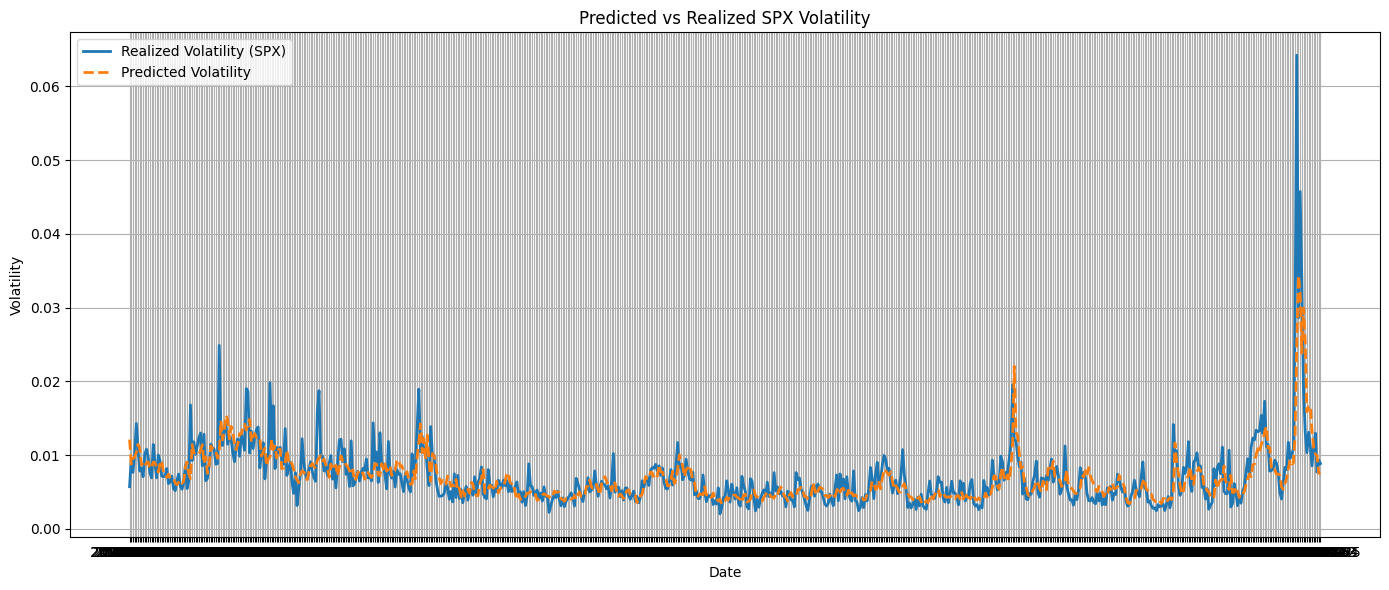

In [148]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(14, 6))
plt.plot(y_true, label='Realized Volatility (SPX)', linewidth=2)
plt.plot(y_pred, label='Predicted Volatility', linewidth=2, linestyle='--')
plt.title('Predicted vs Realized SPX Volatility')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [173]:
import numpy as np

arr = np.array(y_pred)
np.save('pred_markov.npy', arr)



In [176]:
arr = np.array(y_true)
np.save('true_pre.npy', arr)

In [167]:
len(y_pred)

707

In [155]:
len(true_vals)

705

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=c491ba08-7b0b-4e77-bbce-46de4cee5dd0' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>